# 03 — Städa Mustache-datasetet
Laddar den **sparade** modellen från steg 02 och kör den på `data/dataset_v3/` för att hitta felmärkta CelebA-labels (label noise).

Tre delar:
- **A. Felanalys** — vilka bilder gissar modellen fel på, och hur säkert?
- **B. Karantän** — flytta bort de mest extrema/tveksamma fallen helt (krymper datasetet något)
- **C. Omlabla + balansera** — flytta felmärkta clean→mustache och fyll på clean med nya kvinno-bilder (håller datasetet i samma storlek)

Kör om **02_train_mustache_model.ipynb** efter denna för att få den slutgiltiga, städade modellen.

In [31]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array

MODEL_PATH   = 'models/mustache_detector_3.keras'
CLEAN_DIR    = 'data/dataset_v3/clean'
MUSTACHE_DIR = 'data/dataset_v3/mustache'
IMG_SIZE     = (178, 178)
THRESHOLD    = 0.5

model = load_model(MODEL_PATH)
print('Modell laddad!')

Modell laddad!


## A. Felanalys
Kör modellen på alla bilder och bygger en tabell med alla predictions.

In [32]:
rows = []

for true_label, folder, true_name in [
    (0, CLEAN_DIR, 'clean'),
    (1, MUSTACHE_DIR, 'mustache')
]:
    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    for i, fname in enumerate(files):
        path = os.path.join(folder, fname)

        img = load_img(path, target_size=IMG_SIZE)
        arr = img_to_array(img)
        arr = np.expand_dims(arr, axis=0)

        prob = float(model.predict(arr, verbose=0)[0][0])
        pred_label = 1 if prob >= THRESHOLD else 0
        pred_name  = 'mustache' if pred_label == 1 else 'clean'
        confidence = prob if pred_label == 1 else 1 - prob

        rows.append({
            'filename': fname,
            'path': path,
            'true_label': true_label,
            'true_name': true_name,
            'pred_label': pred_label,
            'pred_name': pred_name,
            'mustache_prob': prob,
            'confidence': confidence,
            'correct': pred_label == true_label
        })

        if (i + 1) % 1000 == 0:
            print(f'{true_name}: {i+1}/{len(files)} klara')

df = pd.DataFrame(rows)

print('\nTotalt:', len(df))
print('Rätt:', df['correct'].sum())
print('Fel:', (~df['correct']).sum())
print('Accuracy:', df['correct'].mean())

clean: 1000/5971 klara
clean: 2000/5971 klara
clean: 3000/5971 klara
clean: 4000/5971 klara
clean: 5000/5971 klara
mustache: 1000/5971 klara
mustache: 2000/5971 klara
mustache: 3000/5971 klara
mustache: 4000/5971 klara
mustache: 5000/5971 klara

Totalt: 11942
Rätt: 11674
Fel: 268
Accuracy: 0.9775581979567911


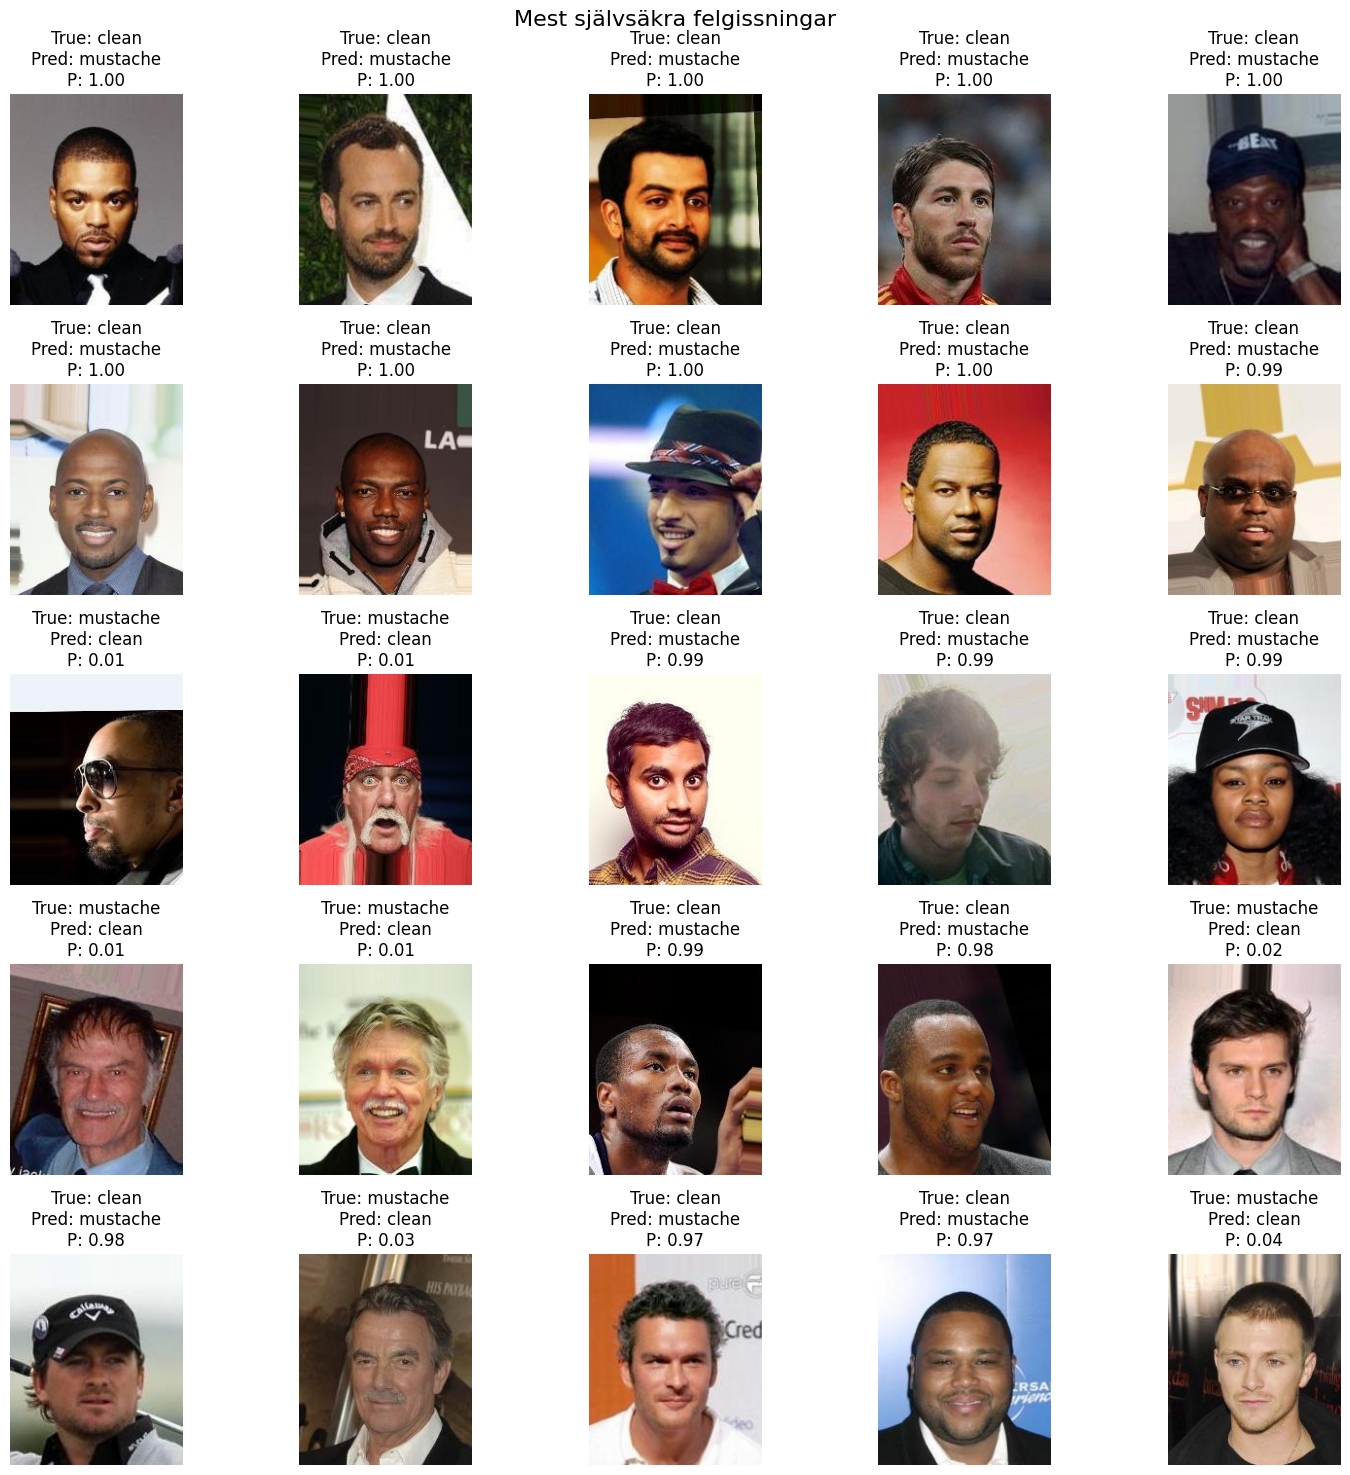

In [27]:
def show_images(dataframe, n=25, title='Felgissningar'):
    sample = dataframe.head(n)
    cols = 5
    rows = int(np.ceil(len(sample) / cols))

    plt.figure(figsize=(15, rows * 3))
    for i, (_, row) in enumerate(sample.iterrows()):
        img = Image.open(row['path'])
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(
            f"True: {row['true_name']}\n"
            f"Pred: {row['pred_name']}\n"
            f"P: {row['mustache_prob']:.2f}"
        )
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


errors = df[df['correct'] == False].copy()
errors = errors.sort_values('confidence', ascending=False)

show_images(errors, n=25, title='Mest självsäkra felgissningar')

Antal clean klassade som mustache: 213


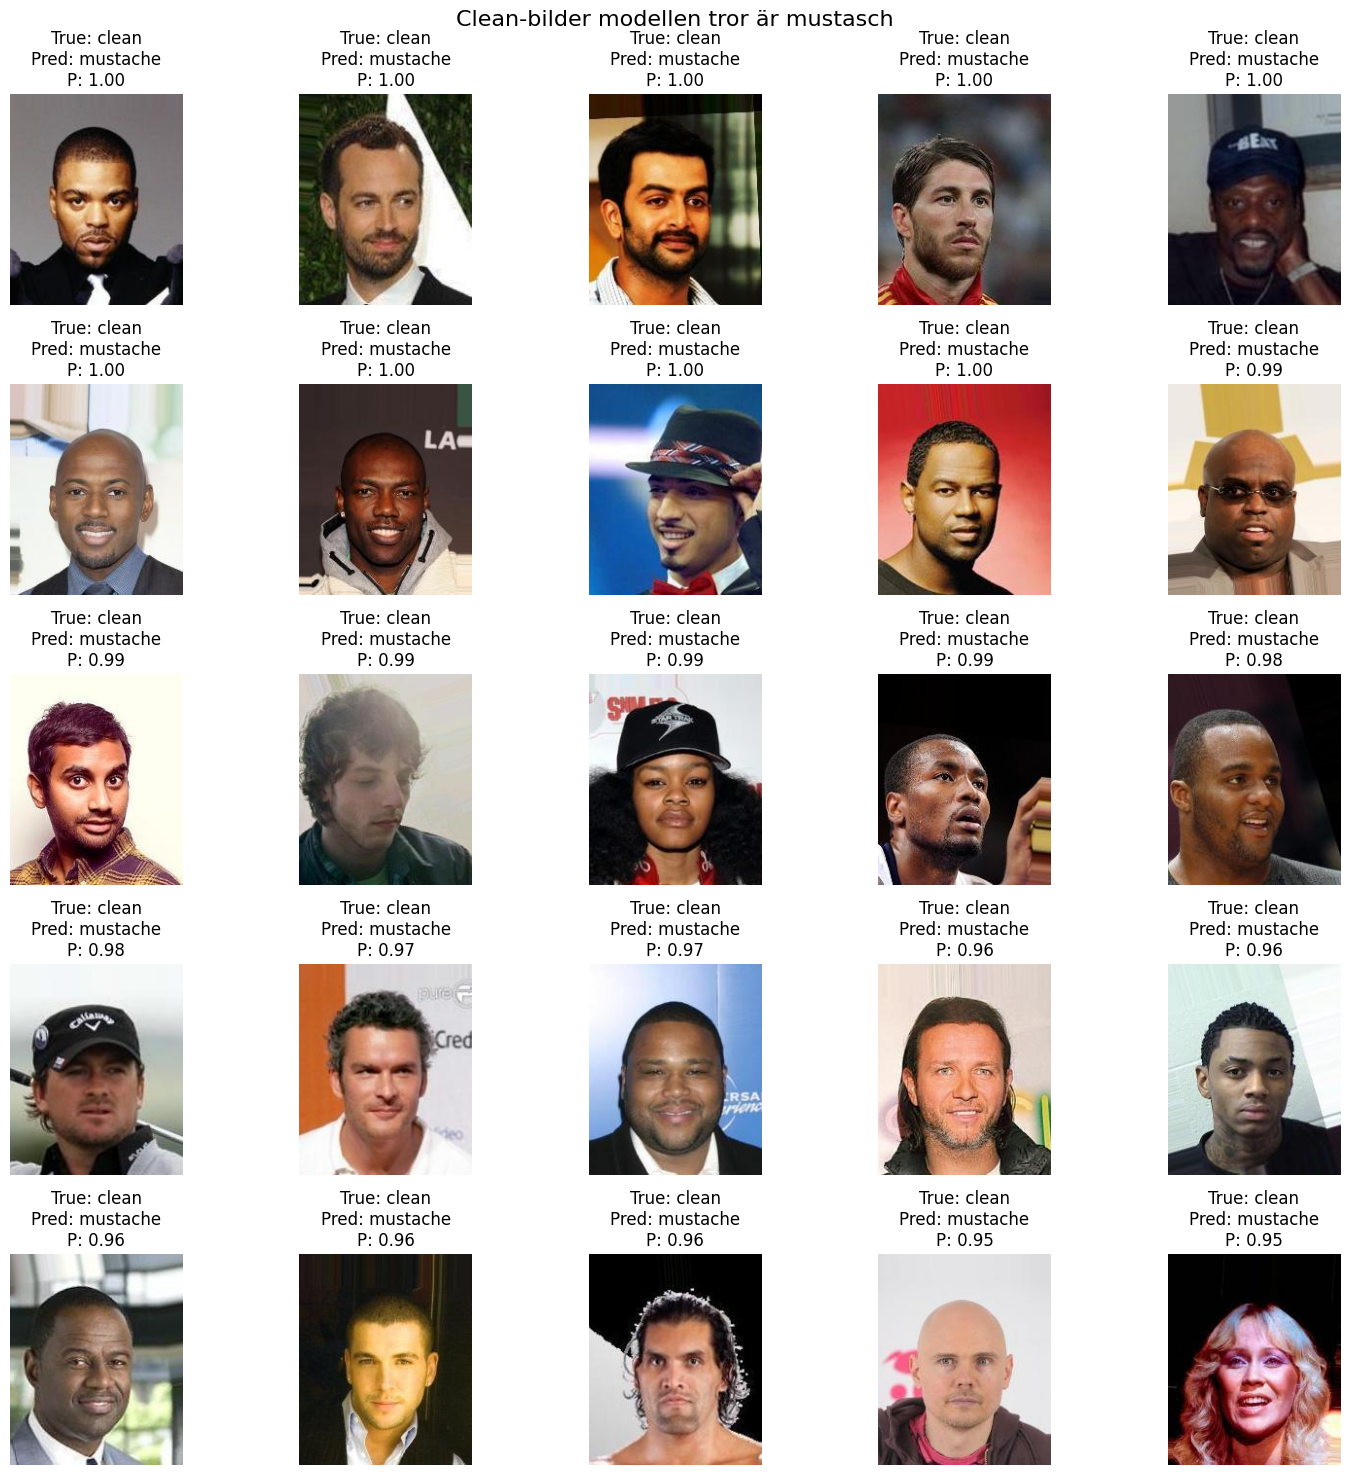

In [28]:
false_mustaches = df[
    (df['true_name'] == 'clean') &
    (df['pred_name'] == 'mustache')
].copy().sort_values('mustache_prob', ascending=False)

print('Antal clean klassade som mustache:', len(false_mustaches))
show_images(false_mustaches, n=25, title='Clean-bilder modellen tror är mustasch')

## Tröskel-utforskning
Hjälper dig välja en bra `THRESHOLD` för del B och C nedan.

In [24]:
print('Clean klassade som mustache, vid olika trösklar:')
for t in [0.50, 0.60, 0.65, 0.70, 0.75, 0.80]:
    n = len(df[
        (df['true_name'] == 'clean') &
        (df['pred_name'] == 'mustache') &
        (df['mustache_prob'] >= t)
    ])
    print(f'  >= {t}: {n}')

print('\nMustasch klassade som clean, vid olika trösklar:')
for t in [0.05, 0.10, 0.15, 0.20]:
    n = len(df[
        (df['true_name'] == 'mustache') &
        (df['pred_name'] == 'clean') &
        (df['mustache_prob'] <= t)
    ])
    print(f'  <= {t}: {n}')

Clean klassade som mustache, vid olika trösklar:
  >= 0.5: 213
  >= 0.6: 162
  >= 0.65: 134
  >= 0.7: 110
  >= 0.75: 96
  >= 0.8: 84

Mustasch klassade som clean, vid olika trösklar:
  <= 0.05: 8
  <= 0.1: 18
  <= 0.15: 24
  <= 0.2: 35


## B. Karantän (valfritt)
Flyttar de **mest extrema** felen helt ur datasetet — varken kvar i clean eller mustache. Bra för bilder som är genuint tveksamma snarare än bara felmärkta.

In [29]:
QUARANTINE_DIR_CLEAN = 'data/quarantine/mustache_predicted_clean'
QUARANTINE_DIR_MUST  = 'data/quarantine/clean_predicted_mustache'
os.makedirs(QUARANTINE_DIR_CLEAN, exist_ok=True)
os.makedirs(QUARANTINE_DIR_MUST, exist_ok=True)

errors = df[df['correct'] == False]

for _, row in errors.iterrows():
    src = row['path']
    dst_dir = QUARANTINE_DIR_CLEAN if row['true_name'] == 'mustache' else QUARANTINE_DIR_MUST
    dst = os.path.join(dst_dir, row['filename'])
    if os.path.exists(src):
        shutil.move(src, dst)

print(f'Flyttade {len(errors)} bilder till karantän totalt')

Flyttade 319 bilder till karantän totalt


In [12]:
QUARANTINE_DIR = 'data/quarantine/mustache_predicted_clean'
os.makedirs(QUARANTINE_DIR, exist_ok=True)

candidates = df[
    (df['true_name'] == 'mustache') &
    (df['pred_name'] == 'clean') &
    (df['mustache_prob'] <= 0.05)
]

for _, row in candidates.iterrows():
    src = row['path']
    dst = os.path.join(QUARANTINE_DIR, row['filename'])
    if os.path.exists(src):
        shutil.move(src, dst)

print(f'Flyttade {len(candidates)} bilder till karantän (mustache_predicted_clean)')

Flyttade 18 bilder till karantän (mustache_predicted_clean)


In [13]:
QUARANTINE_DIR = 'data/quarantine/clean_predicted_mustache'
os.makedirs(QUARANTINE_DIR, exist_ok=True)

candidates = df[
    (df['true_name'] == 'clean') &
    (df['pred_name'] == 'mustache') &
    (df['mustache_prob'] >= 0.95)
]

for _, row in candidates.iterrows():
    src = row['path']
    dst = os.path.join(QUARANTINE_DIR, row['filename'])
    if os.path.exists(src):
        shutil.move(src, dst)

print(f'Flyttade {len(candidates)} bilder till karantän (clean_predicted_mustache)')

Flyttade 25 bilder till karantän (clean_predicted_mustache)


## C. Omlabla + balansera
Flyttar resterande felmärkta clean→mustache (riktiga mustaschbilder felmärkta i CelebA), och fyller på clean med nya kvinno-bilder så datasetet hålls balanserat.

In [ ]:
NOISE_THRESHOLD = 0.70

to_relabel = df[
    (df['true_name'] == 'clean') &
    (df['pred_name'] == 'mustache') &
    (df['mustache_prob'] >= NOISE_THRESHOLD)
]

for _, row in to_relabel.iterrows():
    src = row['path']
    dst = os.path.join(MUSTACHE_DIR, row['filename'])
    if os.path.exists(src):
        shutil.move(src, dst)

print(f'Flyttade {len(to_relabel)} felmärkta clean → mustache')
print(f'Clean nu:    {len(os.listdir(CLEAN_DIR))}')
print(f'Mustache nu: {len(os.listdir(MUSTACHE_DIR))}')

In [ ]:
labels     = pd.read_csv('data/list_attr_celeba.csv')
source_dir = 'data/img/img_align_celeba'
women      = labels[labels['Male'] == -1]

already_used = set(os.listdir(CLEAN_DIR)) | set(os.listdir(MUSTACHE_DIR))
women_pool    = women[(women['Mustache'] == -1) & (women['Black_Hair'] == 1)]
women_pool    = women_pool[~women_pool['image_id'].isin(already_used)]

n_mustache = len(os.listdir(MUSTACHE_DIR))
n_clean    = len(os.listdir(CLEAN_DIR))
n_needed   = n_mustache - n_clean

print(f'Behöver {n_needed} fler bilder i clean för balans')

if n_needed > 0:
    fill = women_pool.sample(n=n_needed, random_state=99)
    for filename in fill['image_id']:
        src = os.path.join(source_dir, filename)
        dst = os.path.join(CLEAN_DIR, filename)
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.copy2(src, dst)

print(f'Clean nu:    {len(os.listdir(CLEAN_DIR))}')
print(f'Mustache nu: {len(os.listdir(MUSTACHE_DIR))}')

## Klart!
Gå tillbaka till **02_train_mustache_model.ipynb** och kör om — det blir din slutgiltiga, städade modell.

## D. Fyll på med big-lips-exempel (valfritt)
Modellen har visat tendens att förväxla fylliga/mörka läppar med mustasch. Fyller eventuellt kvarvarande gap i clean med `Big_Lips`-bilder (CelebA-attribut) istället för bara kvinnor — riktar in sig specifikt på den förväxlingen. Additiv, rör inte befintliga bilder (även icke-CelebA-bilder du lagt till manuellt).

In [30]:
labels     = pd.read_csv('data/list_attr_celeba.csv')
source_dir = 'data/img/img_align_celeba'

n_mustache = len(os.listdir(MUSTACHE_DIR))
n_clean    = len(os.listdir(CLEAN_DIR))
n_needed   = n_mustache - n_clean

print(f'Behöver {n_needed} fler bilder i clean')

already_used = set(os.listdir(CLEAN_DIR)) | set(os.listdir(MUSTACHE_DIR))

big_lips_pool = labels[
    (labels['Mustache'] == -1) &
    (labels['Big_Lips'] == 1) &
    (~labels['image_id'].isin(already_used))
]

print(f'Tillgängliga big-lips-kandidater: {len(big_lips_pool)}')

if n_needed > 0:
    fill = big_lips_pool.sample(n=min(n_needed, len(big_lips_pool)), random_state=123)

    for filename in fill['image_id']:
        src = os.path.join(source_dir, filename)
        dst = os.path.join(CLEAN_DIR, filename)
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.copy2(src, dst)

print(f'Clean nu:    {len(os.listdir(CLEAN_DIR))}')
print(f'Mustache nu: {len(os.listdir(MUSTACHE_DIR))}')

Behöver 98 fler bilder i clean
Tillgängliga big-lips-kandidater: 44059
Clean nu:    5971
Mustache nu: 5971
